# ReviewInsight - NLP Project

In [1]:
# 1. Setup
#%pip install -q numpy pandas openpyxl scikit-learn matplotlib seaborn torch

import copy, json, os, random, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix)
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = Path.cwd()
REPORT_DIR = BASE_DIR / 'reports' / 'notebook'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep')

print(f"ReviewInsight is ready\nDevice: {DEVICE} | Seed: {SEED} | Reports: {REPORT_DIR}")

ReviewInsight is ready
Device: cpu | Seed: 42 | Reports: c:\Users\User\Code\NLP\ReviewInsight\reports\notebook


## 1. Load `Dataset.xlsx`



In [24]:
DATA_FILE = BASE_DIR / 'Dataset.xlsx'
# Example: DATA_FILE = Path(r'C:/Users/you/Downloads/Dataset.xlsx')
if not DATA_FILE.exists():
    matches = list(BASE_DIR.glob('*.xlsx')) + list(BASE_DIR.glob('*.xls'))                          #0 . find and load dataset file
    if matches: DATA_FILE = matches[0]
if not DATA_FILE.exists():
    raise FileNotFoundError(f'Place Dataset.xlsx beside the notebook or update DATA_FILE. Checked: {BASE_DIR}')

raw = pd.read_excel(DATA_FILE)
def guess_column(columns, names):
    normalized = {str(c).strip().lower(): c for c in columns}
    for name in names:
        if name in normalized: return normalized[name]
    for key, original in normalized.items():
        if any(name in key for name in names): return original
    return None

REVIEW_COL = guess_column(raw.columns, ['review_text','review','text','comment'])                   #1 . identify review colum
RATING_COL = guess_column(raw.columns, ['ratings_int','rating','ratings','stars','score'])          #2 . identify rating colum

if REVIEW_COL is None or RATING_COL is None:
    raise ValueError(f'Could not detect columns. Available columns: {list(raw.columns)}')

print(f"Loaded {DATA_FILE.name} | Review column: {REVIEW_COL} | Rating column: {RATING_COL} | Rows: {len(raw):,}")
display(raw.head(5))
display(pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum(), 'unique': raw.nunique()}))

Loaded Dataset.xlsx | Review column: review_text | Rating column: ratings_int | Rows: 43,061


,reviewer_name,ratings,ratings_int,review_text,restaurant,city,translated_text
0,Fatema,1/5,1,The amount of food very very less.,Barcode Cafe_Chittagong,Chittagong,The amount of food very very less.
1,Priya,4/5,4,Food packaging good. Ordered fried rice set me...,Barcode Cafe_Chittagong,Chittagong,Food packaging good. Ordered fried rice set me...
2,Maimuna,2/5,2,"the rice was horrible, Idk why barcode does it...",Barcode Cafe_Chittagong,Chittagong,"the rice was horrible, Idk why barcode does it..."
3,Samantha,1/5,1,I ordered something and received something else,Barcode Cafe_Chittagong,Chittagong,I ordered something and received something else
4,Meraj,3/5,3,it was ok. half the pizza slid off the bread b...,Barcode Cafe_Chittagong,Chittagong,it was ok. half the pizza slide off the bread ...


,dtype,missing,unique
reviewer_name,str,9,9872
ratings,str,0,5
ratings_int,int64,0,5
review_text,str,0,35515
restaurant,str,0,382
city,str,0,8
translated_text,str,0,34883


## 2. Clean and validate data

*Goal: `raw dataset` ➔ `usable review + rating dataset`*

<div align="center">

**[ Raw Reviews & Ratings ]**
<br>⬇<br>
**Clean Text**
<br>⬇<br>
**Convert Ratings to Numeric**
<br>⬇<br>
**Remove Invalid Ratings**
<br>⬇<br>
**Filter Ratings (1–5)**
<br>⬇<br>
**Remove Short Reviews**
<br>⬇<br>
**Convert Ratings to Integer**
<br>⬇<br>
**Remove Duplicates**
<br>⬇<br>
**Add Word Count**
<br>⬇<br>
**[ Clean Dataset ]**
</div>

Conflicting duplicate reviews: 567
Duplicate rows merged: 9,305
Final rows: 33,329

Data quality summary
Original rows: 43,061 | Invalid/short rows removed: 427 | Duplicate rows merged: 9,305 | Final rows: 33,329


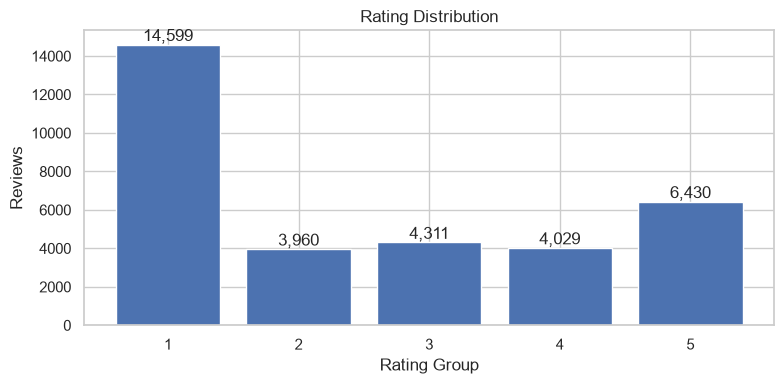

In [ ]:
def clean_review(value):
    if pd.isna(value):  return ''
    value = unicodedata.normalize('NFC',str(value).lower())
    value = re.sub(r'[^a-z\u0980-\u09FF!?\s]','',value)             # Keep only English letters, Bangla characters, !, ?, and spaces
    return re.sub(r'\s+', ' ', value).strip()                       # Replace multiple spaces with one space


# Create clean dataframe
data = pd.DataFrame({'review': raw[REVIEW_COL].map(clean_review),'rating': pd.to_numeric(raw[RATING_COL],errors='coerce')})
original_rows = len(data)

# Remove invalid rows
data = data.dropna(subset=['rating'])
data = data[data['rating'].between(1, 5) &(data['review'].str.len() > 2)].copy()

# Original dataset ratings are treated as 1–5 integer labels
data['rating'] = data['rating'].round().astype(int)
after_filtering = len(data)
invalid_removed = original_rows - after_filtering


# Check conflicting duplicate reviews : Same review text but different ratings
conflicting_reviews = (data.groupby('review')['rating'].nunique().gt(1).sum())
print("Conflicting duplicate reviews:",conflicting_reviews)

# Merge duplicate reviews : Same review → mean of all available ratings
before_duplicates = len(data)
data = (data.groupby('review', as_index=False)['rating'].mean())
duplicates_merged = before_duplicates - len(data)
data['rating_stratify'] = (data['rating'].round().clip(1, 5).astype(int))

# Number of words in each review
data['word_count'] = (data['review'].str.split().str.len())


# Data quality summary
print(f"Duplicate rows merged: {duplicates_merged:,}")
print(f"Final rows: {len(data):,}")
print(f"\nData quality summary\n"f"Original rows: {original_rows:,} | "f"Invalid/short rows removed: {invalid_removed:,} | "f"Duplicate rows merged: {duplicates_merged:,} | "f"Final rows: {len(data):,}")



fig, ax = plt.subplots(figsize=(8, 4))
counts = (data['rating_stratify'].value_counts().sort_index())
bars = ax.bar(counts.index.astype(str),counts.values)
ax.set(title='Rating Distribution',xlabel='Rating Group', ylabel='Reviews')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f'{int(bar.get_height()):,}',ha='center',va='bottom')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'rating_distribution.png',dpi=180)
plt.show()

## 3. Stratified split and training-only tokenizer

In [ ]:

# Train / Validation / Test Split
# 70%   10%    20%  

train_df, temp_df = train_test_split(data,test_size=0.30,random_state=SEED,stratify=data['rating_stratify'])
val_df, test_df = train_test_split(temp_df,test_size=2/3,random_state=SEED,stratify=temp_df['rating_stratify'])

print(f"Train: {len(train_df):,} | "f"Validation: {len(val_df):,} | "f"Test: {len(test_df):,}")

# Show rating-group distribution of each split
split_counts = pd.DataFrame({'train':train_df['rating_stratify'].value_counts(),'validation':val_df['rating_stratify'].value_counts(),'test':test_df['rating_stratify'].value_counts()})
split_counts = (split_counts.fillna(0).sort_index().astype(int))

display(split_counts.style.background_gradient(cmap='Blues'))


# Tokenizer settings
MAX_VOCAB = 15000
MAX_LEN = 120

class Tokenizer:

    def __init__(self, max_vocab):
        self.max_vocab = max_vocab
        self.word_index = {'<OOV>': 1}                   # 0 is reserved for padding  1 is reserved for unknown words

    def fit(self, texts):

        # Count frequency of every word
        counts = Counter(word for text in texts for word in text.split())
        # Keep only most common words
        for i, (word, _) in enumerate(counts.most_common(self.max_vocab - 2),start=2):
            self.word_index[word] = i

    def encode(self, text):
        return [self.word_index.get(word, 1) for word in text.split()]


# Build vocabulary ONLY from training reviews

tokenizer = Tokenizer(MAX_VOCAB)
tokenizer.fit(train_df['review'])


# Convert text → word IDs → padding

def encode_texts(texts):

    rows = []
    lengths = []

    for text in texts:
        seq = tokenizer.encode(text)[:MAX_LEN]
        lengths.append(max(1, len(seq)))
        padded_seq = (seq + [0] * (MAX_LEN - len(seq)))
        rows.append(padded_seq)

    return (np.asarray( rows, dtype=np.int64), np.asarray( lengths, dtype=np.int64 ) )


# Encode all three splits
X_train, L_train = encode_texts(train_df['review'])
X_val, L_val = encode_texts(  val_df['review'])
X_test, L_test = encode_texts(test_df['review'])

y_train = train_df['rating'].to_numpy(float)
y_val = val_df['rating'].to_numpy(float)
y_test = test_df['rating'].to_numpy(float)


print('Training vocabulary:',len(tokenizer.word_index))

Train: 23,330 | Validation: 3,333 | Test: 6,666


,train,validation,test
rating_stratify,,,
1,10219,1460,2920
2,2772,396,792
3,3018,431,862
4,2820,403,806
5,4501,643,1286


Training vocabulary: 14999


## 4. Self-contained regularized BiLSTM

In [31]:
class ReviewDataset(Dataset):
    def __init__(self,X,L,y):
        self.X=torch.tensor(X).long()
        self.L=torch.tensor(L).long()
        self.y=torch.tensor(y).float()

    def __len__(self): 
        return len(self.y)                      #returns count of reviews in the Dataset

    def __getitem__(self,i): 
        return self.X[i],self.L[i],self.y[i]    #return specific review,length of review,rating of the review

class Attention(nn.Module):                     #attention layer. gives custom weights to each words . important word : big weight
    def __init__(self,n): 
        super().__init__()
        self.score=nn.Linear(n,1)

    def forward(self,x,mask):
        weights = self.score(x).squeeze(-1).masked_fill(mask==0,-1e9)
        weights = torch.softmax(weights,1).unsqueeze(-1)
        return (x*weights).sum(1)

class RatingBiLSTM(nn.Module):
    def __init__(self,vocab,embedding=128,hidden=80,dropout=.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab,embedding,padding_idx = 0)
        self.emb_drop = nn.Dropout1d(dropout*.5)
        self.lstm = nn.LSTM(embedding,hidden,batch_first = True,bidirectional = True)
        self.lstm_drop = nn.Dropout(dropout)
        self.attn = Attention(hidden*2)
        self.fc1 = nn.Linear(hidden*6,64)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64,1)

    def forward(self,x,lengths):
        mask = (x!=0).float()
        emb = self.emb_drop(self.embedding(x).transpose(1,2)).transpose(1,2)
        packed = pack_padded_sequence(emb,lengths.cpu(),batch_first = True,enforce_sorted = False)
        packed_out,_ = self.lstm(packed)
        out,_ = pad_packed_sequence(packed_out,batch_first = True,total_length = x.shape[1])
        out = self.lstm_drop(out)
        context = self.attn(out,mask)
        masked = out*mask.unsqueeze(-1)
        avg = masked.sum(1)/mask.sum(1,keepdim = True).clamp(min = 1)
        max_pool = out.masked_fill(mask.unsqueeze(-1) == 0,-float('inf')).max(1).values
        max_pool = torch.nan_to_num(max_pool,nan = 0.,neginf = 0.)
        hidden = torch.relu(self.fc1(torch.cat([context,avg,max_pool],1)))
        return self.fc2(self.drop(hidden)).squeeze(-1)

train_loader = DataLoader(ReviewDataset(X_train,L_train,y_train),batch_size = 64,shuffle = True)
val_loader = DataLoader(ReviewDataset(X_val,L_val,y_val),batch_size = 64)
test_loader = DataLoader(ReviewDataset(X_test,L_test,y_test),batch_size = 64)
model = RatingBiLSTM(len(tokenizer.word_index)+1).to(DEVICE)
print(model)

RatingBiLSTM(
  (embedding): Embedding(15000, 128, padding_idx=0)
  (emb_drop): Dropout1d(p=0.175, inplace=False)
  (lstm): LSTM(128, 80, batch_first=True, bidirectional=True)
  (lstm_drop): Dropout(p=0.35, inplace=False)
  (attn): Attention(
    (score): Linear(in_features=160, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=480, out_features=64, bias=True)
  (drop): Dropout(p=0.35, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Train with validation-MAE early stopping

In [32]:
criterion = nn.HuberLoss(delta = 1.0)
optimizer = torch.optim.AdamW(model.parameters(),lr = 3e-4,weight_decay = 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode = 'min',factor = .5,patience = 2,min_lr = 1e-6)
history = {'train_loss':[],'val_loss':[],'train_mae':[],'val_mae':[]}
best_state = None
best_mae = float('inf')
wait = 0

def epoch(loader,training):
    model.train(training); total=[0.,0.,0.]
    with torch.set_grad_enabled(training):
        for X,L,y in loader:
            X,L,y=X.to(DEVICE),L.to(DEVICE),y.to(DEVICE)
            if training: 
                optimizer.zero_grad()
            pred=model(X,L)
            loss=criterion(pred,y)
            if training: 
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(),1.)
                optimizer.step()
            n=len(y)
            total[0]+=loss.item()*n
            total[1]+=torch.abs(pred-y).sum().item()
            total[2]+=n
    return total[0]/total[2],total[1]/total[2]

for e in range(1,31):
    tl,tm=epoch(train_loader,True)
    vl,vm=epoch(val_loader,False)
    scheduler.step(vm)
    for key,value in zip(history,[tl,vl,tm,vm]): history[key].append(value)
    print(f'Epoch {e:02d} | train MAE {tm:.4f} | val MAE {vm:.4f}')
    if vm<best_mae: 
        best_mae=vm
        best_state=copy.deepcopy(model.state_dict())
        wait=0
    else:
        wait+=1
        if wait>=4: 
            print('Early stopping'); break
model.load_state_dict(best_state)
best_epoch=int(np.argmin(history['val_mae']))+1
print(f'Best epoch: {best_epoch} | validation MAE: {best_mae:.4f}')

Epoch 01 | train MAE 1.3160 | val MAE 0.9907
Epoch 02 | train MAE 0.9933 | val MAE 0.8853
Epoch 03 | train MAE 0.9155 | val MAE 0.8312
Epoch 04 | train MAE 0.8608 | val MAE 0.7982
Epoch 05 | train MAE 0.8261 | val MAE 0.7961
Epoch 06 | train MAE 0.7987 | val MAE 0.7729
Epoch 07 | train MAE 0.7689 | val MAE 0.7652
Epoch 08 | train MAE 0.7520 | val MAE 0.7622
Epoch 09 | train MAE 0.7282 | val MAE 0.7821
Epoch 10 | train MAE 0.7098 | val MAE 0.7618
Epoch 11 | train MAE 0.6962 | val MAE 0.7501
Epoch 12 | train MAE 0.6829 | val MAE 0.7625
Epoch 13 | train MAE 0.6663 | val MAE 0.7545
Epoch 14 | train MAE 0.6556 | val MAE 0.7665
Epoch 15 | train MAE 0.6359 | val MAE 0.7505
Early stopping
Best epoch: 11 | validation MAE: 0.7501


## 6. Training curves

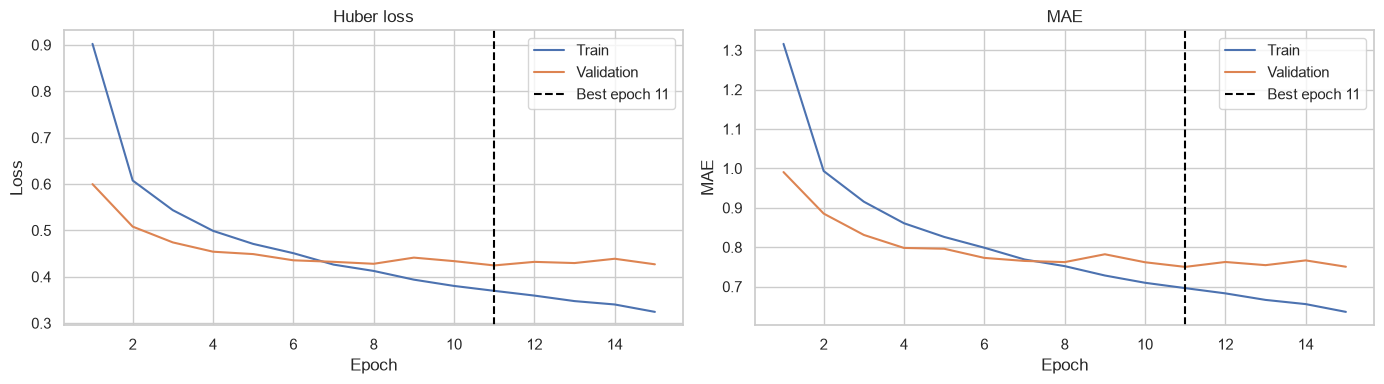

In [33]:
fig,ax=plt.subplots(1,2,figsize=(14,4)); epochs=range(1,len(history['train_loss'])+1)
ax[0].plot(epochs,history['train_loss'],label='Train'); ax[0].plot(epochs,history['val_loss'],label='Validation'); ax[0].axvline(best_epoch,ls='--',c='black',label=f'Best epoch {best_epoch}'); ax[0].set(title='Huber loss',xlabel='Epoch',ylabel='Loss'); ax[0].legend()
ax[1].plot(epochs,history['train_mae'],label='Train'); ax[1].plot(epochs,history['val_mae'],label='Validation'); ax[1].axvline(best_epoch,ls='--',c='black',label=f'Best epoch {best_epoch}'); ax[1].set(title='MAE',xlabel='Epoch',ylabel='MAE'); ax[1].legend(); plt.tight_layout(); plt.savefig(REPORT_DIR/'training_curves.png',dpi=180); plt.show()

## 7. Final test report

In [34]:
model.eval(); predictions=[]
with torch.no_grad():
    for X,L,_ in test_loader: predictions.extend(model(X.to(DEVICE),L.to(DEVICE)).cpu().numpy())
predictions=np.clip(np.asarray(predictions),1,5); actual=y_test.astype(int); rounded=np.rint(predictions).astype(int)
metrics={'MAE':mean_absolute_error(actual,predictions),'RMSE':mean_squared_error(actual,predictions)**.5,'R2':r2_score(actual,predictions),'Exact accuracy':accuracy_score(actual,rounded),'Within +/- 1 star':np.mean(np.abs(actual-rounded)<=1)}
metrics_df=pd.DataFrame({'Metric':metrics.keys(),'Value':metrics.values()}); display(metrics_df.style.format({'Value':'{:.4f}'}).background_gradient(cmap='Blues'))
with open(REPORT_DIR/'metrics.json','w') as f: json.dump({k:float(v) for k,v in metrics.items()},f,indent=2)

,Metric,Value
0,MAE,0.7003
1,RMSE,1.0240
2,R2,0.5822
3,Exact accuracy,0.5086
4,Within +/- 1 star,0.8489


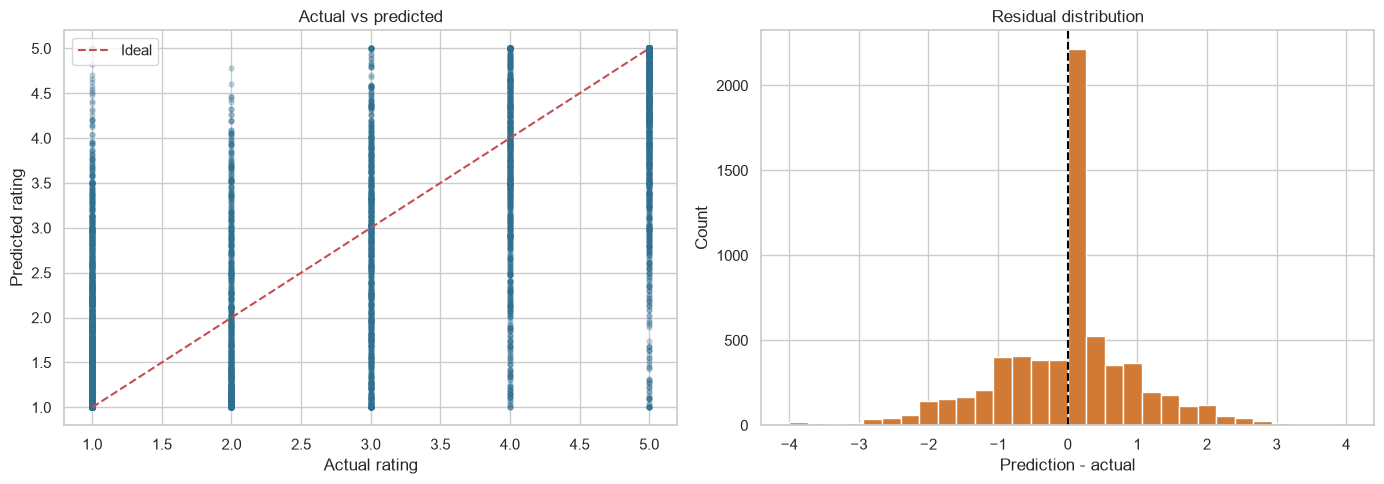

In [35]:
residuals=predictions-actual; fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].scatter(actual,predictions,alpha=.25,s=12,c='#2f6f8f'); ax[0].plot([1,5],[1,5],'r--',label='Ideal'); ax[0].set(title='Actual vs predicted',xlabel='Actual rating',ylabel='Predicted rating'); ax[0].legend()
ax[1].hist(residuals,bins=30,color='#d07a35',edgecolor='white'); ax[1].axvline(0,c='black',ls='--'); ax[1].set(title='Residual distribution',xlabel='Prediction - actual',ylabel='Count'); plt.tight_layout(); plt.savefig(REPORT_DIR/'prediction_diagnostics.png',dpi=180); plt.show()

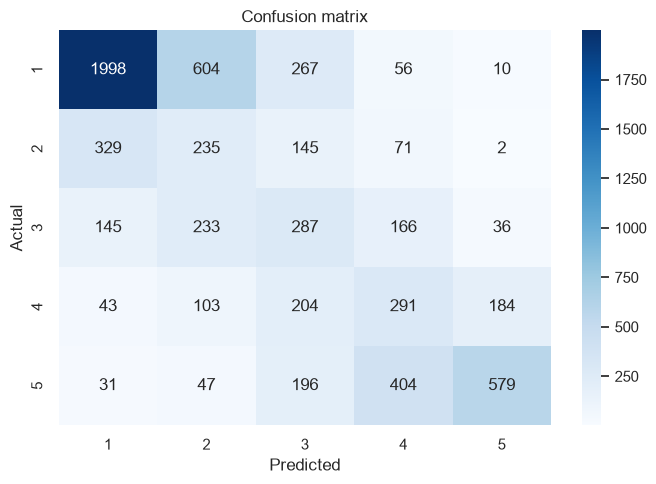

              precision    recall  f1-score   support

           1       0.78      0.68      0.73      2935
           2       0.19      0.30      0.23       782
           3       0.26      0.33      0.29       867
           4       0.29      0.35      0.32       825
           5       0.71      0.46      0.56      1257

    accuracy                           0.51      6666
   macro avg       0.45      0.43      0.43      6666
weighted avg       0.57      0.51      0.53      6666



,Rating,MAE
0,1,0.505709
1,2,0.771595
2,3,0.906835
3,4,0.879424
4,5,0.850148


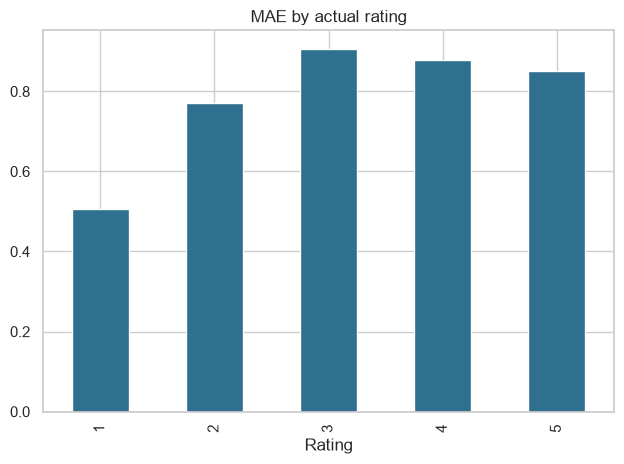

In [36]:
cm=confusion_matrix(actual,rounded,labels=[1,2,3,4,5]); fig,ax=plt.subplots(figsize=(7,5)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=[1,2,3,4,5],yticklabels=[1,2,3,4,5],ax=ax); ax.set(title='Confusion matrix',xlabel='Predicted',ylabel='Actual'); plt.tight_layout(); plt.savefig(REPORT_DIR/'confusion_matrix.png',dpi=180); plt.show()
print(classification_report(actual,rounded,labels=[1,2,3,4,5],zero_division=0))
per_class=pd.DataFrame({'Rating':[r for r in range(1,6) if np.any(actual==r)],'MAE':[mean_absolute_error(actual[actual==r],predictions[actual==r]) for r in range(1,6) if np.any(actual==r)]}); display(per_class.style.background_gradient(cmap='Oranges')); per_class.plot.bar(x='Rating',y='MAE',legend=False,color='#2f6f8f',title='MAE by actual rating'); plt.tight_layout(); plt.savefig(REPORT_DIR/'per_class_mae.png',dpi=180); plt.show()

## 8. Export portable deployment artifacts

In [38]:
ARTIFACT = BASE_DIR/'reviewinsight_model.pt'
bundle={'model_state':model.state_dict(),'vocab':tokenizer.word_index,'max_len':MAX_LEN,'max_vocab':MAX_VOCAB,'embedding_dim':128,'hidden_dim':80,'dropout':.35,'cleaning':'lowercase NFC; English/Bengali letters; !? punctuation'}
torch.save(bundle,ARTIFACT)
data[['review','rating']].to_csv(REPORT_DIR/'cleaned_data.csv',index=False)
print(f'Saved portable model: {ARTIFACT}')
print(f'Saved figures and reports: {REPORT_DIR}')

Saved portable model: c:\Users\User\Code\NLP\ReviewInsight\reviewinsight_model.pt
Saved figures and reports: c:\Users\User\Code\NLP\ReviewInsight\reports\notebook


## 9. Live prediction demo


In [39]:
def validate_review(text, tokenizer):
    cleaned = clean_review(text)
 
    if not cleaned:
        return False, "Please enter a valid text review."

    words = cleaned.split()
 
    if len(words) < 2:
        return False, "Please enter a complete review."
 
    known_words = [
        word for word in words
        if word in tokenizer.word_index
    ]
 
    if len(known_words) < 2:
        return False, "The text does not look like a valid review."

    known_ratio = len(known_words) / len(words)
 
    if known_ratio < 0.5:
        return False, "Too many unknown words."

    return True, cleaned

def predict_review(review_text):

    valid, result = validate_review(review_text, tokenizer)

    if not valid:
        return {
            'review': review_text,
            'error': result
        }

    cleaned = result

    X, L = encode_texts([cleaned])

    model.eval()

    with torch.no_grad():
        score = float(
            model(
                torch.tensor(X).to(DEVICE),
                torch.tensor(L).to(DEVICE)
            ).item()
        )

    score = float(np.clip(score, 1, 5))
    rounded = int(np.clip(np.rint(score), 1, 5))

    sentiment = (
        'Positive' if rounded >= 4
        else 'Neutral' if rounded == 3
        else 'Negative'
    )

    return {
        'review': review_text,
        'predicted_rating': round(score, 2),
        'rounded_rating': rounded,
        'sentiment': sentiment
    }

demo_reviews=['The food was delicious and delivery was fast','খাবার ঠান্ডা এসেছে এবং সার্ভিস খুব খারাপ','Food was okay but delivery was late']
demo=pd.DataFrame([predict_review(text) for text in demo_reviews]); display(demo.style.set_properties(**{'text-align':'left'}).background_gradient(subset=['predicted_rating'],cmap='Blues'))

print(predict_review("123456"))
print(predict_review("sdfsdf 3werwer"))
print(predict_review("good"))
print(predict_review("food was excellent"))

,review,predicted_rating,rounded_rating,sentiment
0,The food was delicious and delivery was fast,4.670000,5,Positive
1,খাবার ঠান্ডা এসেছে এবং সার্ভিস খুব খারাপ,1.140000,1,Negative
2,Food was okay but delivery was late,2.310000,2,Negative


{'review': '123456', 'error': 'Please enter a valid text review.'}
{'review': 'sdfsdf 3werwer', 'error': 'The text does not look like a valid review.'}
{'review': 'good', 'error': 'Please enter a complete review.'}
{'review': 'food was excellent', 'predicted_rating': 4.83, 'rounded_rating': 5, 'sentiment': 'Positive'}


127.0.0.1 - - [23/Sep/2026 02:04:08] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:09] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [23/Sep/2026 02:04:18] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:21] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:25] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:29] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:31] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 02:04:33] "POST /predict HTTP/1.1" 200 -


## 10. Local deployment API


Endpoints:

- `GET /health` confirms that the model is loaded.
- `POST /predict` accepts JSON such as `{"review": "The food was excellent"}`.

In [ ]:
%pip install -q flask

import threading
import urllib.request
from flask import Flask, Response, jsonify, request
from werkzeug.serving import make_server

if not ARTIFACT.exists():
    raise FileNotFoundError('Run the export cell first so reviewinsight_model.pt exists.')

# Reload from the portable artifact. No local .py file is needed.
loaded = torch.load(ARTIFACT, map_location=DEVICE)
api_tokenizer = loaded['vocab']
api_model = RatingBiLSTM(
    len(api_tokenizer) + 1,
    loaded['embedding_dim'],
    loaded['hidden_dim'],
    loaded['dropout'],
).to(DEVICE)
api_model.load_state_dict(loaded['model_state'])
api_model.eval()
api_max_len = loaded['max_len']

def api_encode(text):
    sequence = [api_tokenizer.get(word, 1) for word in clean_review(text).split()][:api_max_len]
    padded = sequence + [0] * (api_max_len - len(sequence))
    return np.asarray([padded], dtype=np.int64), np.asarray([max(1, len(sequence))], dtype=np.int64)

def api_predict(text):
    X, L = api_encode(text)
    with torch.no_grad():
        score = float(api_model(torch.tensor(X).to(DEVICE), torch.tensor(L).to(DEVICE)).item())
    score = float(np.clip(score, 1, 5))
    return {
        'rating': round(score, 2),
        'rounded_rating': int(np.clip(np.rint(score), 1, 5)),
        'sentiment': 'Positive' if score >= 4 else ('Neutral' if score >= 3 else 'Negative'),
    }

#HTML Web Page Code
WEB_PAGE = r'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>ReviewInsight | AI Rating Predictor</title>

    <style>
        /* =========================================================
           RESET
        ========================================================= */
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        :root {
            --primary: #6366f1;
            --primary-dark: #4f46e5;
            --secondary: #8b5cf6;
            --pink: #ec4899;
            --text-main: #172033;
            --text-muted: #7b8499;
            --border: rgba(148, 163, 184, 0.20);
            --card: rgba(255, 255, 255, 0.94);
            --soft-bg: #f7f8fc;
        }

        html {
            scroll-behavior: smooth;
        }

        body {
            font-family:
                Inter,
                "Segoe UI",
                "Noto Sans Bengali",
                Arial,
                sans-serif;

            min-height: 100vh;

            background:
                radial-gradient(circle at 10% 20%, rgba(99, 102, 241, 0.22), transparent 34%),
                radial-gradient(circle at 90% 80%, rgba(139, 92, 246, 0.22), transparent 34%),
                linear-gradient(135deg, #f8f9ff 0%, #eef1ff 45%, #f8f4ff 100%);

            color: var(--text-main);

            display: flex;
            justify-content: center;
            align-items: center;

            padding: 40px 20px;

            overflow-x: hidden;
            position: relative;
        }


        /* =========================================================
           ANIMATED BACKGROUND
        ========================================================= */

        .background-shape {
            position: fixed;
            border-radius: 50%;
            filter: blur(10px);
            opacity: 0.45;
            pointer-events: none;
            z-index: 0;
        }

        .shape-1 {
            width: 320px;
            height: 320px;
            background: linear-gradient(135deg, #6366f1, #8b5cf6);
            top: -110px;
            left: -80px;
            animation: floatOne 10s ease-in-out infinite alternate;
        }

        .shape-2 {
            width: 280px;
            height: 280px;
            background: linear-gradient(135deg, #ec4899, #8b5cf6);
            right: -100px;
            bottom: -80px;
            animation: floatTwo 12s ease-in-out infinite alternate;
        }

        .shape-3 {
            width: 160px;
            height: 160px;
            background: #818cf8;
            top: 30%;
            right: 6%;
            opacity: 0.18;
            animation: floatThree 9s ease-in-out infinite alternate;
        }

        @keyframes floatOne {
            from {
                transform: translate(0, 0) rotate(0deg);
            }
            to {
                transform: translate(40px, 45px) rotate(15deg);
            }
        }

        @keyframes floatTwo {
            from {
                transform: translate(0, 0) scale(1);
            }
            to {
                transform: translate(-45px, -30px) scale(1.1);
            }
        }

        @keyframes floatThree {
            from {
                transform: translateY(-15px);
            }
            to {
                transform: translateY(30px);
            }
        }


        /* =========================================================
           MAIN WRAPPER
        ========================================================= */

        .page-wrapper {
            width: 100%;
            max-width: 780px;
            position: relative;
            z-index: 2;
        }

        .container {
            width: 100%;

            background: var(--card);

            border: 1px solid rgba(255, 255, 255, 0.75);
            border-radius: 28px;

            padding: 42px;

            box-shadow:
                0 30px 80px rgba(61, 65, 120, 0.16),
                0 4px 15px rgba(30, 41, 59, 0.05);

            backdrop-filter: blur(20px);
            -webkit-backdrop-filter: blur(20px);

            animation: containerEnter 0.75s cubic-bezier(.2,.8,.2,1);
        }

        @keyframes containerEnter {
            from {
                opacity: 0;
                transform: translateY(25px) scale(0.98);
            }

            to {
                opacity: 1;
                transform: translateY(0) scale(1);
            }
        }


        /* =========================================================
           HEADER
        ========================================================= */

        .header {
            text-align: center;
            margin-bottom: 34px;
        }

        .logo {
            width: 66px;
            height: 66px;

            margin: 0 auto 16px;

            display: flex;
            align-items: center;
            justify-content: center;

            border-radius: 20px;

            background:
                linear-gradient(
                    135deg,
                    var(--primary),
                    var(--secondary)
                );

            font-size: 31px;

            box-shadow:
                0 14px 32px rgba(99, 102, 241, 0.28);

            animation: logoFloat 4s ease-in-out infinite;
        }

        @keyframes logoFloat {
            0%, 100% {
                transform: translateY(0);
            }

            50% {
                transform: translateY(-6px);
            }
        }

        .header h1 {
            font-size: 2.55rem;
            font-weight: 800;
            letter-spacing: -1.5px;
            line-height: 1.15;
        }

        .header h1 span {
            background:
                linear-gradient(
                    135deg,
                    var(--primary),
                    var(--secondary),
                    var(--pink)
                );

            -webkit-background-clip: text;
            background-clip: text;
            -webkit-text-fill-color: transparent;
        }

        .header p {
            margin-top: 10px;

            color: var(--text-muted);
            font-size: 1rem;
            line-height: 1.6;
        }

        .ai-badge {
            margin-top: 14px;

            display: inline-flex;
            align-items: center;
            gap: 7px;

            font-size: 0.78rem;
            font-weight: 700;

            padding: 7px 13px;

            border-radius: 999px;

            color: var(--primary-dark);
            background: rgba(99, 102, 241, 0.09);

            border: 1px solid rgba(99, 102, 241, 0.13);
        }

        .pulse-dot {
            width: 7px;
            height: 7px;

            border-radius: 50%;

            background: #22c55e;

            box-shadow:
                0 0 0 0 rgba(34, 197, 94, 0.5);

            animation: pulse 2s infinite;
        }

        @keyframes pulse {
            0% {
                box-shadow: 0 0 0 0 rgba(34,197,94,.45);
            }

            70% {
                box-shadow: 0 0 0 8px rgba(34,197,94,0);
            }

            100% {
                box-shadow: 0 0 0 0 rgba(34,197,94,0);
            }
        }


        /* =========================================================
           INPUT CARD
        ========================================================= */

        .input-section {
            background: #fbfbfe;

            border: 1px solid var(--border);
            border-radius: 20px;

            padding: 18px;

            transition:
                border-color 0.25s ease,
                box-shadow 0.25s ease,
                transform 0.25s ease;
        }

        .input-section:focus-within {
            border-color: rgba(99, 102, 241, 0.45);

            box-shadow:
                0 0 0 4px rgba(99, 102, 241, 0.08);

            transform: translateY(-1px);
        }

        .input-header {
            display: flex;
            align-items: center;
            justify-content: space-between;

            margin-bottom: 11px;
        }

        .input-label {
            display: flex;
            align-items: center;
            gap: 8px;

            font-size: 0.9rem;
            font-weight: 700;
            color: #424a5e;
        }

        .char-count {
            font-size: 0.75rem;
            color: #9aa2b2;
        }

        textarea {
            width: 100%;
            min-height: 140px;

            border: none;
            outline: none;

            resize: vertical;

            background: transparent;

            color: var(--text-main);

            font-family: inherit;
            font-size: 1rem;
            line-height: 1.7;

            transition: all 0.2s ease;
        }

        textarea::placeholder {
            color: #adb4c3;
        }

        .input-footer {
            display: flex;
            justify-content: flex-end;

            margin-top: 8px;

            color: #9aa2b2;
            font-size: 0.76rem;
        }

        .shortcut {
            display: flex;
            align-items: center;
            gap: 5px;
        }

        kbd {
            padding: 3px 7px;

            border: 1px solid #d9dce5;
            border-radius: 6px;

            background: white;

            box-shadow:
                0 2px 3px rgba(0,0,0,0.05);

            color: #6a7282;

            font-family: inherit;
            font-size: 0.70rem;
        }


        /* =========================================================
           BUTTON
        ========================================================= */

        .btn-primary {
            position: relative;

            width: 100%;

            margin-top: 18px;

            padding: 15px 25px;

            border: none;
            border-radius: 16px;

            overflow: hidden;

            cursor: pointer;

            font-family: inherit;
            font-size: 1rem;
            font-weight: 700;

            color: white;

            background:
                linear-gradient(
                    135deg,
                    var(--primary),
                    var(--secondary)
                );

            box-shadow:
                0 12px 28px rgba(99, 102, 241, 0.25);

            transition:
                transform 0.25s ease,
                box-shadow 0.25s ease,
                opacity 0.25s ease;
        }

        .btn-primary::before {
            content: "";

            position: absolute;
            top: 0;
            left: -120%;

            width: 80%;
            height: 100%;

            background:
                linear-gradient(
                    90deg,
                    transparent,
                    rgba(255,255,255,0.35),
                    transparent
                );

            transform: skewX(-20deg);

            transition: left 0.55s ease;
        }

        .btn-primary:hover::before {
            left: 140%;
        }

        .btn-primary:hover {
            transform: translateY(-2px);

            box-shadow:
                0 16px 36px rgba(99, 102, 241, 0.32);
        }

        .btn-primary:active {
            transform: translateY(0) scale(0.99);
        }

        .btn-primary:disabled {
            opacity: 0.6;
            cursor: not-allowed;

            transform: none;
            box-shadow: none;
        }


        /* =========================================================
           LOADER
        ========================================================= */

        .loader {
            display: none;

            margin-top: 22px;

            border-radius: 18px;

            padding: 25px;

            text-align: center;

            background:
                linear-gradient(
                    135deg,
                    rgba(99,102,241,0.04),
                    rgba(139,92,246,0.06)
                );

            border:
                1px solid rgba(99,102,241,0.10);
        }

        .loader.show {
            display: block;

            animation: fadeUp 0.35s ease;
        }

        .spinner {
            width: 44px;
            height: 44px;

            margin: 0 auto;

            border: 4px solid rgba(99,102,241,0.12);
            border-top-color: var(--primary);

            border-radius: 50%;

            animation: spin 0.8s linear infinite;
        }

        @keyframes spin {
            to {
                transform: rotate(360deg);
            }
        }

        .loader-title {
            margin-top: 13px;

            font-weight: 700;
            font-size: 0.95rem;

            color: #50586c;
        }

        .loader-text {
            margin-top: 4px;

            color: #969dad;

            font-size: 0.80rem;
        }


        /* =========================================================
           RESULT
        ========================================================= */

        .result {
            display: none;

            position: relative;

            margin-top: 24px;

            padding: 30px 22px;

            overflow: hidden;

            border-radius: 22px;

            text-align: center;

            background:
                linear-gradient(
                    145deg,
                    #fafaff,
                    #f5f3ff
                );

            border:
                1px solid rgba(99,102,241,0.10);
        }

        .result::before {
            content: "";

            position: absolute;

            width: 220px;
            height: 220px;

            border-radius: 50%;

            background:
                radial-gradient(
                    circle,
                    rgba(99,102,241,0.12),
                    transparent 70%
                );

            top: -130px;
            right: -80px;
        }

        .result.show {
            display: block;

            animation:
                resultEnter 0.55s cubic-bezier(.2,.8,.2,1);
        }

        @keyframes resultEnter {
            from {
                opacity: 0;
                transform: translateY(18px) scale(0.97);
            }

            to {
                opacity: 1;
                transform: translateY(0) scale(1);
            }
        }

        @keyframes fadeUp {
            from {
                opacity: 0;
                transform: translateY(8px);
            }

            to {
                opacity: 1;
                transform: translateY(0);
            }
        }

        .result-label {
            color: var(--text-muted);

            font-size: 0.75rem;
            font-weight: 800;

            letter-spacing: 1.6px;

            text-transform: uppercase;

            margin-bottom: 15px;
        }

        .stars-container {
            display: flex;
            align-items: center;
            justify-content: center;

            gap: 5px;
        }

        .star-svg {
            width: 46px;
            height: 46px;

            display: block;

            filter:
                drop-shadow(0 5px 8px rgba(244, 180, 0, 0.16));

            animation: starPop 0.45s ease both;
        }

        .star-svg:nth-child(1) { animation-delay: 0.05s; }
        .star-svg:nth-child(2) { animation-delay: 0.10s; }
        .star-svg:nth-child(3) { animation-delay: 0.15s; }
        .star-svg:nth-child(4) { animation-delay: 0.20s; }
        .star-svg:nth-child(5) { animation-delay: 0.25s; }

        @keyframes starPop {
            from {
                opacity: 0;
                transform: scale(0.55) rotate(-10deg);
            }

            to {
                opacity: 1;
                transform: scale(1) rotate(0);
            }
        }

        .star-bg {
            fill: #dfe2e9;
        }

        .star-fg {
            fill: #f4b400;
        }

        .rating-number {
            margin-top: 9px;

            font-size: 3.25rem;
            line-height: 1;

            font-weight: 800;

            letter-spacing: -2px;

            color: #202637;
        }

        .rating-number small {
            font-size: 1rem;

            font-weight: 600;
            color: #8c94a5;

            letter-spacing: 0;
        }

        .sentiment {
            display: inline-flex;
            align-items: center;
            justify-content: center;

            margin-top: 16px;

            padding: 9px 20px;

            border-radius: 999px;

            font-size: 0.93rem;
            font-weight: 700;

            transition: all 0.3s ease;
        }


        /* =========================================================
           EXAMPLES
        ========================================================= */

        .examples {
            margin-top: 28px;
        }

        .examples-header {
            display: flex;
            align-items: center;
            justify-content: space-between;

            margin-bottom: 12px;
        }

        .examples-title {
            font-size: 0.85rem;
            font-weight: 700;

            color: #666f83;
        }

        .examples-subtitle {
            font-size: 0.72rem;

            color: #a1a7b4;
        }

        .example-buttons {
            display: flex;
            flex-wrap: wrap;

            gap: 9px;
        }

        .example-btn {
            border: 1px solid rgba(148,163,184,0.18);

            background: #f8f9fc;

            color: #596175;

            padding: 8px 13px;

            border-radius: 999px;

            cursor: pointer;

            font-family: inherit;
            font-size: 0.78rem;
            font-weight: 600;

            transition:
                background 0.2s ease,
                color 0.2s ease,
                border-color 0.2s ease,
                transform 0.2s ease,
                box-shadow 0.2s ease;
        }

        .example-btn:hover {
            color: var(--primary-dark);

            background: rgba(99,102,241,0.08);

            border-color: rgba(99,102,241,0.20);

            transform: translateY(-2px);

            box-shadow:
                0 6px 18px rgba(99,102,241,0.10);
        }


        /* =========================================================
           FOOTER
        ========================================================= */

        .footer {
            margin-top: 27px;

            padding-top: 19px;

            border-top:
                1px solid rgba(148,163,184,0.12);

            display: flex;
            align-items: center;
            justify-content: center;

            gap: 6px;

            color: #a0a6b3;

            font-size: 0.74rem;
        }

        .footer strong {
            color: #7d8494;
        }


        /* =========================================================
           TOAST
        ========================================================= */

        .toast {
            position: fixed;

            left: 50%;
            bottom: 30px;

            transform:
                translate(-50%, 30px);

            z-index: 100;

            background: #161b28;
            color: white;

            padding: 12px 18px;

            border-radius: 12px;

            font-size: 0.85rem;
            font-weight: 600;

            box-shadow:
                0 12px 32px rgba(0,0,0,0.22);

            opacity: 0;
            pointer-events: none;

            transition:
                opacity 0.3s ease,
                transform 0.3s ease;
        }

        .toast.show {
            opacity: 1;

            transform:
                translate(-50%, 0);
        }


        /* =========================================================
           RESPONSIVE
        ========================================================= */

        @media (max-width: 640px) {

            body {
                padding: 20px 14px;
                align-items: flex-start;
            }

            .container {
                margin-top: 12px;

                padding: 28px 20px;

                border-radius: 23px;
            }

            .logo {
                width: 57px;
                height: 57px;

                font-size: 27px;

                border-radius: 17px;
            }

            .header h1 {
                font-size: 2rem;
            }

            .header p {
                font-size: 0.9rem;
            }

            .input-section {
                padding: 15px;
            }

            textarea {
                min-height: 125px;
            }

            .star-svg {
                width: 36px;
                height: 36px;
            }

            .rating-number {
                font-size: 2.7rem;
            }

            .examples-header {
                display: block;
            }

            .examples-subtitle {
                margin-top: 4px;
            }

            .example-btn {
                font-size: 0.73rem;
            }

            .shortcut {
                display: none;
            }
        }


        /* =========================================================
           ACCESSIBILITY
        ========================================================= */

        @media (prefers-reduced-motion: reduce) {

            *,
            *::before,
            *::after {
                animation-duration: 0.01ms !important;
                animation-iteration-count: 1 !important;
                scroll-behavior: auto !important;
                transition-duration: 0.01ms !important;
            }
        }

    </style>
</head>


<body>

    <!-- Decorative animated background -->
    <div class="background-shape shape-1"></div>
    <div class="background-shape shape-2"></div>
    <div class="background-shape shape-3"></div>


    <main class="page-wrapper">

        <div class="container">

            <!-- ================= HEADER ================= -->

            <div class="header">

                <div class="logo">
                    🍽️
                </div>

                <h1>
                    <span>ReviewInsight</span>
                </h1>

                <p>
                    Intelligent food review analysis and rating prediction.
                </p>

                <div class="ai-badge">
                    <span class="pulse-dot"></span>
                    AI Rating Prediction
                </div>

            </div>


            <!-- ================= INPUT ================= -->

            <div class="input-section">

                <div class="input-header">

                    <div class="input-label">
                        ✍️ Your Review
                    </div>

                    <div class="char-count">
                        <span id="charCount">0</span> characters
                    </div>

                </div>

                <textarea
                    id="reviewInput"
                    maxlength="1000"
                    placeholder="Write your food delivery review here...

Example: খাবারটা অনেক ভালো ছিল এবং ডেলিভারি খুব দ্রুত এসেছে।"
                ></textarea>


                <div class="input-footer">

                    <div class="shortcut">
                        Press
                        <kbd>Ctrl</kbd>
                        +
                        <kbd>Enter</kbd>
                        to predict
                    </div>

                </div>

            </div>


            <!-- ================= BUTTON ================= -->

            <button
                class="btn-primary"
                id="predictBtn"
                onclick="predict()"
            >
                <span id="buttonText">
                    ✨ Analyze Review
                </span>
            </button>


            <!-- ================= LOADING ================= -->

            <div class="loader" id="loader">

                <div class="spinner"></div>

                <div class="loader-title">
                    Analyzing your review
                </div>

                <div class="loader-text">
                    Our model is estimating the most likely rating...
                </div>

            </div>


            <!-- ================= RESULT ================= -->

            <div class="result" id="result">

                <div class="result-label">
                    Predicted Rating
                </div>

                <div
                    class="stars-container"
                    id="starsDisplay"
                ></div>

                <div
                    class="rating-number"
                    id="ratingDisplay"
                ></div>

                <div
                    class="sentiment"
                    id="sentimentDisplay"
                ></div>

            </div>


            <!-- ================= EXAMPLES ================= -->

            <div class="examples">

                <div class="examples-header">

                    <div class="examples-title">
                        💡 Try an example
                    </div>

                    <div class="examples-subtitle">
                        Click to automatically fill the review
                    </div>

                </div>

                <div class="example-buttons">

                    <button
                        class="example-btn"
                        onclick="setExample(0)"
                    >
                        😊 Good Food
                    </button>

                    <button
                        class="example-btn"
                        onclick="setExample(1)"
                    >
                        😕 Bad Quality
                    </button>

                    <button
                        class="example-btn"
                        onclick="setExample(2)"
                    >
                        ⚖️ Mixed Review
                    </button>

                    <button
                        class="example-btn"
                        onclick="setExample(3)"
                    >
                        ⭐ Perfect
                    </button>

                    <button
                        class="example-btn"
                        onclick="setExample(4)"
                    >
                        😠 Poor Service
                    </button>

                </div>

            </div>


            <!-- ================= FOOTER ================= -->

            <div class="footer">
                Powered by
                <strong>ReviewInsight NLP</strong>
                · Bangla & Banglish supported
            </div>

        </div>

    </main>


    <!-- Toast Notification -->

    <div class="toast" id="toast"></div>


<script>

    /* =========================================================
       EXAMPLE REVIEWS
    ========================================================= */

    const examples = [

        "খাবারটা খুব সুস্বাদু ছিল, ডেলিভারিও সময়মতো এসেছে",

        "খাবার ঠান্ডা এসেছে এবং কোয়ালিটি ভালো ছিল না",

        "Food ta khub tasty chilo but delivery late",

        "অনেক ভালো খাবার  । কোয়ালিটি এবং স্বাদ সেরা ",

        "খাবার খারাপ, ডেলিভারি লেট, সার্ভিস খুবই খারাপ"

    ];


    /* =========================================================
       ELEMENTS
    ========================================================= */

    const reviewInput =
        document.getElementById("reviewInput");

    const predictBtn =
        document.getElementById("predictBtn");

    const loader =
        document.getElementById("loader");

    const result =
        document.getElementById("result");

    const charCount =
        document.getElementById("charCount");

    const buttonText =
        document.getElementById("buttonText");


    /* =========================================================
       CHARACTER COUNTER
    ========================================================= */

    reviewInput.addEventListener("input", function () {

        charCount.textContent =
            reviewInput.value.length;

    });


    /* =========================================================
       STAR RENDERING
    ========================================================= */

    function renderStars(rating) {

        const value =
            Math.max(
                0,
                Math.min(
                    5,
                    Number(rating) || 0
                )
            );

        let html = "";


        for (let i = 1; i <= 5; i++) {

            let fill =
                value - (i - 1);

            fill =
                Math.max(
                    0,
                    Math.min(1, fill)
                );


            const clipId =
                "starClip_" +
                i +
                "_" +
                Math.random()
                    .toString(36)
                    .substring(2, 8);


            const fillPercent =
                (fill * 100).toFixed(1);


            html += `

                <svg
                    class="star-svg"
                    viewBox="0 0 24 24"
                    xmlns="http://www.w3.org/2000/svg"
                >

                    <defs>

                        <clipPath id="${clipId}">

                            <rect
                                x="0"
                                y="0"
                                width="${fillPercent}%"
                                height="24"
                            />

                        </clipPath>

                    </defs>


                    <path
                        class="star-bg"
                        d="
                            M12 2
                            l3.09 6.26
                            L22 9.27
                            l-5 4.87
                            1.18 6.88
                            L12 17.77
                            l-6.18 3.25
                            L7 14.14
                            2 9.27
                            l6.91-1.01
                            L12 2z
                        "
                    />


                    <path
                        class="star-fg"
                        clip-path="url(#${clipId})"
                        d="
                            M12 2
                            l3.09 6.26
                            L22 9.27
                            l-5 4.87
                            1.18 6.88
                            L12 17.77
                            l-6.18 3.25
                            L7 14.14
                            2 9.27
                            l6.91-1.01
                            L12 2z
                        "
                    />

                </svg>

            `;
        }


        return html;
    }


    /* =========================================================
       EXAMPLES
    ========================================================= */

    function setExample(index) {

        reviewInput.value =
            examples[index];

        charCount.textContent =
            examples[index].length;

        result.classList.remove("show");

        reviewInput.focus();

    }


    /* =========================================================
       TOAST
    ========================================================= */

    let toastTimer;


    function showToast(message) {

        const toast =
            document.getElementById("toast");

        toast.textContent =
            message;

        toast.classList.add("show");


        clearTimeout(toastTimer);


        toastTimer =
            setTimeout(() => {

                toast.classList.remove("show");

            }, 2800);

    }


    /* =========================================================
       PREDICT
    ========================================================= */

    async function predict() {

        const review =
            reviewInput.value.trim();


        if (!review) {

            showToast(
                "Please write a review first."
            );

            reviewInput.focus();

            return;

        }


        /* Show loading */

        loader.classList.add("show");

        result.classList.remove("show");

        predictBtn.disabled = true;

        buttonText.textContent =
            "Analyzing...";


        try {

            const response =
                await fetch(
                    "/predict",
                    {
                        method: "POST",

                        headers: {
                            "Content-Type":
                                "application/json"
                        },

                        body: JSON.stringify({
                            review: review
                        })
                    }
                );


                const data = await response.json();

                if (!response.ok) {
                    throw new Error(
                        data.error || ("Server returned " + response.status)
                    );
                }

                if (data.error) {
                    throw new Error(data.error);
                }


            /* Rating */

            document
                .getElementById(
                    "starsDisplay"
                )
                .innerHTML =
                renderStars(data.rating);


            document
                .getElementById(
                    "ratingDisplay"
                )
                .innerHTML =
                `${data.rating} <small>/ 5.0</small>`;


            /* Sentiment */

            const sentiment =
                document.getElementById(
                    "sentimentDisplay"
                );


            sentiment.textContent =
                data.sentiment;


            const resultColor =
                data.color || "#6366f1";


            sentiment.style.backgroundColor =
                resultColor + "15";


            sentiment.style.color =
                resultColor;


            sentiment.style.border =
                `1px solid ${resultColor}30`;


            /* Show result */

            loader.classList.remove("show");


            requestAnimationFrame(() => {

                result.classList.add("show");

            });


        }

        catch (error) {

            console.error(error);

            showToast(error.message);

        }   

        finally {

            loader.classList.remove("show");

            predictBtn.disabled = false;

            buttonText.textContent =
                "✨ Analyze Review";

        }

    }


    /* =========================================================
       CTRL + ENTER SHORTCUT
    ========================================================= */

    reviewInput.addEventListener(
        "keydown",
        function (event) {

            if (
                event.key === "Enter" &&
                event.ctrlKey
            ) {

                event.preventDefault();

                predict();

            }

        }
    );

</script>

</body>
</html>'''

api = Flask('reviewinsight_notebook_api')
@api.get('/')
def home():
    return Response(WEB_PAGE, mimetype='text/html')

@api.get('/health')
def health():
    return jsonify({'status': 'ok', 'model_loaded': True, 'device': str(DEVICE)})

@api.post('/predict')
def predict_endpoint():
    payload = request.get_json(silent=True) or {}
    review = str(payload.get('review', '')).strip()
    valid, result = validate_review(review, tokenizer)
    if not valid:
        return jsonify({
            'error': result
        }), 400

    return jsonify(api_predict(review))

class NotebookServer:
    def __init__(self, flask_app, host='127.0.0.1', port=0):
        self.server = make_server(host, port, flask_app)
        self.thread = threading.Thread(target=self.server.serve_forever, daemon=True)
    @property
    def url(self):
        return f'http://{self.server.host}:{self.server.port}'
    def start(self):
        self.thread.start()
    def stop(self):
        self.server.shutdown()

deployment_server = NotebookServer(api)
deployment_server.start()
print(f'Site running at: {deployment_server.url}/')
print(f'Health endpoint: {deployment_server.url}/health')
print('Stop it later with: deployment_server.stop()')


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Site running at: http://127.0.0.1:56318/
Health endpoint: http://127.0.0.1:56318/health
Stop it later with: deployment_server.stop()


127.0.0.1 - - [22/Sep/2026 23:54:16] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:54:19] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:54:26] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:55:13] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:55:18] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:55:25] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:59:16] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:59:21] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:59:25] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:59:27] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [22/Sep/2026 23:59:29] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 00:00:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 00:01:55] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 00:02:03] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [23/Sep/2026 00:02:11] "POST /predict HTTP